In [ ]:
import numpy as np
import matplotlib.pyplot as plt

1. Реализуйте 1 шаг градиентного спуска для сети с несколькими входами

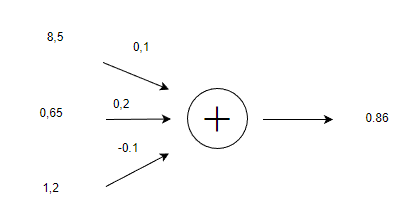

In [ ]:
def w_sum(a, b):
    return sum(a[i] * b[i] for i in range(len(a)))

def neural_network(input_data, weights):
    return w_sum(input_data, weights)

games =  [8.5, 9.5, 9.9, 9.0] # среднее число игр, сыгранных каждым игроком в сезоне
wins= [0.65, 0.8, 0.8, 0.9] # доля побед
nfans = [1.2, 1.3, 0.5, 1.0] # число фанатов в тысячах
win_or_lose_binary = [1, 1, 0, 1] # целевые значения выхода сети

target = win_or_lose_binary[0]
input = [games[0],wins[0],nfans[0]]

weights = [0.1, 0.2, -.1] # W
new_weights = []
learning_rate  = 0.02

# Выполните Шаг градиентного спуска

# предсказание
pred = neural_network(input, weights)

# ошибка
error = (pred - target) ** 2

# шаг градиентного спуска
new_weights = []
for i in range(len(weights)):
    derivative = 2 * input[i] * (pred - target)
    new_weights.append(weights[i] - learning_rate * derivative)

print("pred:", neural_network(input,weights))
print("error:", error)

print("Weights:" + str(weights))
print("New Weights:" + str(new_weights))
print("New pred:", neural_network(input,new_weights))

pred: 0.8600000000000001
error: 0.01959999999999997
Weights:[0.1, 0.2, -0.1]
New Weights:[0.14759999999999995, 0.20364000000000002, -0.09328000000000002]
New pred: 1.2750299999999994


2. Сделайте  несколько итераций градиентного спуска.Постройте графики error/weight. Отметьте на графиках как меняется соответсвующий вес в процессе обучения.

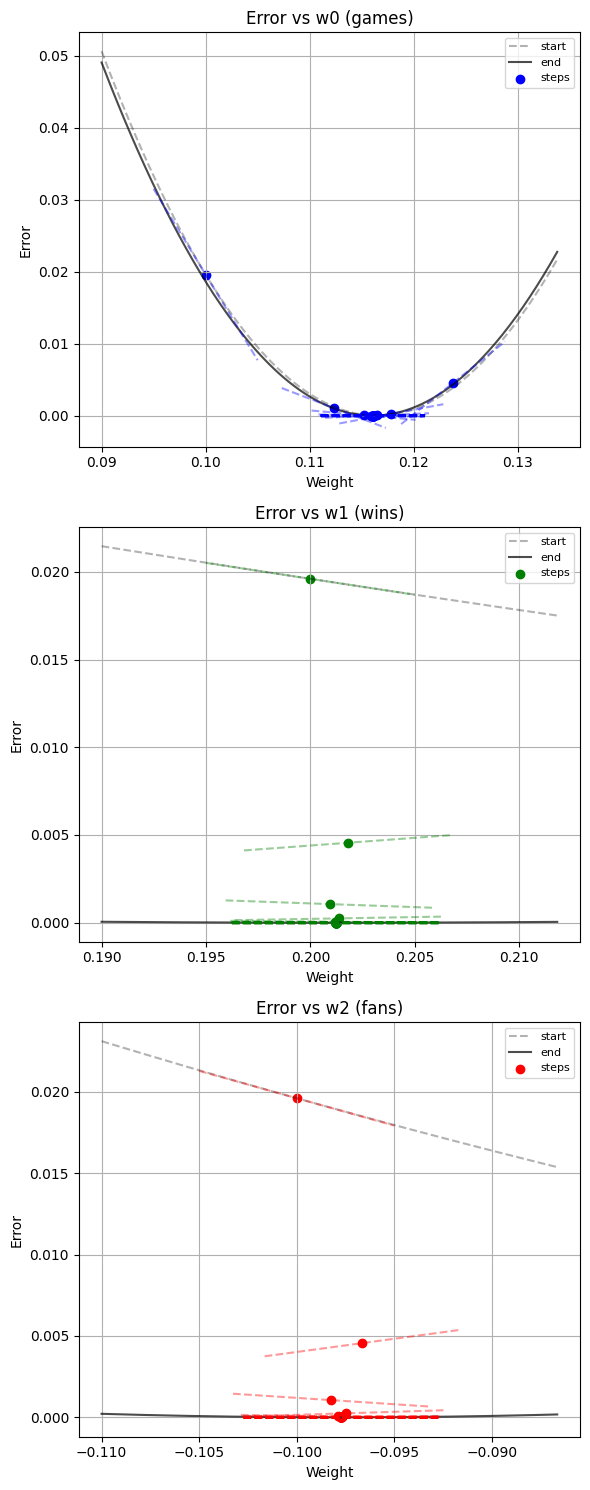

Начальные веса: [0.1, 0.2, -0.1]
Финальные веса: [0.11605667060212517, 0.2012278630460448, -0.09773317591499407]
Начальная ошибка: 0.0196
Финальная ошибка: 0.0
Начальный pred: 0.8600000000000001
Финальный pred: 1.0000000000000002


In [ ]:
def w_sum(a, b):
    return sum(a[i] * b[i] for i in range(len(a)))

def neural_network(input_data, weights):
    return w_sum(input_data, weights)

games = [8.5, 9.5, 9.9, 9.0]
wins = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
win_or_lose_binary = [1, 1, 0, 1]

target = win_or_lose_binary[0]
input_data = [games[0], wins[0], nfans[0]]

# начальные веса
weights = [0.1, 0.2, -0.1]
learning_rate = 0.02
iterations = 50

# история обучения
error_history = []
weights_history = []
derivatives_history = []

# градиентный спуск
for iteration in range(iterations):
    pred = neural_network(input_data, weights)
    error = (pred - target) ** 2

    error_history.append(error)
    weights_history.append(weights[:])

    derivatives = []
    for i in range(len(weights)):
        derivatives.append(input_data[i] * (pred - target))  # без 2
    derivatives_history.append(derivatives[:])

    new_weights = []
    for i in range(len(weights)):
        new_weights.append(weights[i] - learning_rate * derivatives[i])
    weights = new_weights

# построение графиков
fig, axes = plt.subplots(3, 1, figsize=(6, 15))
labels = ['w0 (games)', 'w1 (wins)', 'w2 (fans)']
colors = ['blue', 'green', 'red']

for w_idx in range(3):
    ax = axes[w_idx]

    w_values = [w[w_idx] for w in weights_history]

    w_min = min(w_values) - 0.01
    w_max = max(w_values) + 0.01
    w_range = np.linspace(w_min, w_max, 200)

    # кривая ошибки (начальные веса)
    error_start = []
    for w_val in w_range:
        test_weights = weights_history[0][:]
        test_weights[w_idx] = w_val
        pred = neural_network(input_data, test_weights)
        error_start.append((pred - target) ** 2)

    # кривая ошибки (финальные веса)
    error_end = []
    for w_val in w_range:
        test_weights = weights_history[-1][:]
        test_weights[w_idx] = w_val
        pred = neural_network(input_data, test_weights)
        error_end.append((pred - target) ** 2)

    # кривые
    ax.plot(w_range, error_start, 'k--', alpha=0.3, label='start')
    ax.plot(w_range, error_end, 'k-', alpha=0.7, label='end')

    # точки обучения
    ax.scatter(w_values, error_history, c=colors[w_idx], label='steps')

    # касательные
    for i in range(len(weights_history)):
        w_val = weights_history[i][w_idx]
        err_val = error_history[i]
        grad = 2 * derivatives_history[i][w_idx]

        x_vals = [w_val - 0.005, w_val + 0.005]
        y_vals = [err_val + grad * (x - w_val) for x in x_vals]

        ax.plot(x_vals, y_vals, '--', color=colors[w_idx], alpha=0.4)

    ax.set_xlabel('Weight')
    ax.set_ylabel('Error')
    ax.set_title(f'Error vs {labels[w_idx]}')
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# вывод
print("Начальные веса:", weights_history[0])
print("Финальные веса:", weights_history[-1])
print("Начальная ошибка:", round(error_history[0], 6))
print("Финальная ошибка:", round(error_history[-1], 8))
print("Начальный pred:", neural_network(input_data, weights_history[0]))
print("Финальный pred:", neural_network(input_data, weights_history[-1]))

# Для какого веса наклон касательной больше?

Наибольший наклон касательной будет у веса w0, так как ему соответствует наибольшее значение входного признака. (w0: 8.5, w1: 0.65, w2: 1.2)

# К чему приводит большой наклон касательной при коррекции веса?  

Чем больше наклон касательной, тем сильнее изменяется вес на каждой итерации.
